# Redes Neuronales Convolucionales



**Principales variables a manipular:**

- Batch: subconjunto del conjunto de entrenamiento utilizado para actualizar los pesos del modelo una vez durante el entrenamiento; permite procesar los datos en partes para optimizar memoria y velocidad. El batch agrupa la población/ observaciones del dataset, no sus variables. En python identificaremos a la cantidad de batches por época como " steps_per_epoch".

- Epoch: Una pasada completa por todo el conjunto de entrenamiento durante el entrenamiento del modelo, es decir, a la totalidad de los batches.

- Batch size: Número de muestras procesadas antes de actualizar los pesos del modelo. Por ejemplo, si el batch size es 64, cada batch contiene 64 observaciones del dataset.

- Learning rate: Tasa que determina cuánto se ajustan los pesos del modelo en cada actualización. Una mayor learning rate acelera el aprendizaje pero puede hacer que el modelo se salte el mínimo de la función de pérdida.
Una menor learning rate permite converger con más precisión, pero hace el entrenamiento más lento y puede quedar atascado en mínimos locales.

- Capa de entrada: es la que recibe los valores de las variables (features) de cada observación; funciona como puerta de entrada a la red neuronal.

- Capa de salida: es la que devuelve la predicción final. En clasificación, la cantidad de nodos en la capa de salida depende de la cantidad de clases. El número de nodos en un problema de clasificación binomial será 1 el cual contará con una función de activación sigmoide. En una red de clasificación multinomial será de 1 nodo por cada clase a predecir. En problemas de regresión habrá un único nodo de salida para predecir un valor continuo.

- Capas ocultas: Son las encargadas de procesar la información internamente mediante cálculos con pesos y funciones de activación. En ellas ocurre el aprendizaje, ya que transforman los datos de entrada en representaciones cada vez más abstractas para resolver la tarea. Pueden ser una o varias, dependiendo de la complejidad del modelo.


---


- Función de activación: Función matemática que introduce no linealidad, permitiendo que la red aprenda relaciones complejas (ej: ReLU, softmax).

- Función de costo (pérdida): Mide el error entre la predicción del modelo y el valor real para guiar el aprendizaje (ej: categorical crossentropy).

- Optimizador: Algoritmo que ajusta los pesos del modelo para minimizar la función de pérdida (ej: Adam, SGD).

  - SGD (Stochastic Gradient Descent): Actualiza los pesos usando el gradiente de cada lote. Es simple pero puede ser lento y sensible a la tasa de aprendizaje.
  - Adam (Adaptive Moment Estimation): Combina las ideas de momentum y ajuste adaptativo de la tasa de aprendizaje para cada peso. Es el más usado por su eficiencia y buen rendimiento en muchos casos.
  - RMSprop: Ajusta la tasa de aprendizaje según una media móvil de los cuadrados de los gradientes. Funciona bien en problemas con datos secuenciales o no estacionarios.
  - Adagrad: Adapta la tasa de aprendizaje para cada parámetro, haciéndola más pequeña cuanto más se actualiza. Es útil para datos dispersos (sparse), pero puede volverse demasiado conservador.
  - Nadam: Es una combinación entre Adam y Nesterov momentum, ofreciendo una convergencia más rápida en algunos escenarios.

- Pesos y sesgos (bias): Parámetros que aprende la red para realizar predicciones precisas. Se inicializan aleatoria y automáticamente mediante métodos predefinidos por la biblioteca donde habitualmente los sesgos comienzan en 0. En muchos casos se utilizan estrategias específicas para asignar valores iniciales a los pesos antes del entrenamiento (ej: He, Glorot).

- Regularización: Técnica para evitar el sobreajuste penalizando pesos grandes (ej: L2, dropout). L2 (regularización de pesos o weight decay) penaliza los pesos grandes agregando una suma de los cuadrados de los pesos a la función de pérdida. Esto incentiva a la red a aprender pesos más pequeños, favoreciendo modelos más simples y menos propensos al sobreajuste. L1: Penaliza el valor absoluto de los pesos, favoreciendo que algunos se reduzcan exactamente a cero, lo que simplifica el modelo y selecciona automáticamente características.Dropout apaga aleatoriamente un porcentaje de neuronas durante cada paso del entrenamiento. Esto obliga a la red a no depender de neuronas específicas y a distribuir el aprendizaje, mejorando la robustez del modelo.



---


- Callbacks: Funciones opcionales que se ejecutan durante el entrenamiento para realizar acciones como detener el entrenamiento temprano o guardar el modelo.

- Evaluación del modelo: Métricas que se usan para medir el rendimiento (ej: accuracy, precision, recall).

- Predicción (inferencia): Proceso de usar el modelo ya entrenado para hacer predicciones sobre nuevos datos.

# TENSOR
¿Qué es un tensor?
Un tensor es una estructura matemática que generaliza escalars, vectores y matrices a más dimensiones:

- Escalar	0D	5
- Vector	1D	[5, 2, 3]
- Matriz	2D	[[1, 2], [3, 4]]
- Tensor	3D o más. Una pila de matrices

## Algunas características relevantes
### Orden de los registros en el Batch
Por defecto, los registros se agrupan  aleatoriamente en cada época (shuffle=True en Keras), y luego se dividen en batches del tamaño especificado.
Esto:
- Evita que el modelo aprenda patrones artificiales por el orden de los datos.
- Mejora la generalización.
- Los batches se arman aleatoriamente en cada época salvo que indiquemos lo contrario. Si shuffle=False, se arman en orden.

### Cantidad y tamaño de los batches.

- Sí se puede usar una cantidad de batches menor o mayor, pero implica usar menos datos o repetirlos.
- Se recomienda respetar el tamaño total del dataset dividiendo apropiadamente.

### Tipos de capas
- Conv2D	Extrae características espaciales locales
- MaxPooling2D	Reduce el tamaño y resalta lo más importante
- Flatten	Convierte a vector 1D para usar en capa densa
- Dropout	Reduce el riesgo de sobreajuste
- Dense	Clasifica en una de las 10 clases (0 al 9





# Fuente de inspiración para la notebook


**Author:** [fchollet](https://twitter.com/fchollet)<br>
**Date created:** 2015/06/19<br>
**Last modified:** 2020/04/21<br>
**Description:** A simple convnet that achieves ~99% test accuracy on MNIST.

# Librerías

In [1]:
import numpy as np  # Biblioteca para trabajar con arrays y operaciones numéricas
import keras        # API de alto nivel para construir y entrenar modelos de redes neuronales
from keras import layers  # Módulo para acceder a las capas (layers) de Keras
import matplotlib.pyplot as plt # Necesitamos una librería como matplotlib para visualizar datasets con imágenes


2026-03-11 16:07:31.315142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773266851.337234    1698 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773266851.344831    1698 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773266851.364809    1698 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773266851.364849    1698 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773266851.364852    1698 computation_placer.cc:177] computation placer alr

# Establecemos una semilla para garantizar la reproducibilidad del modelo

In [3]:
import tensorflow as tf
import random

# Establecer la semilla
seed_value = 42

# 1. Semilla para Python
random.seed(seed_value)

# 2. Semilla para NumPy
np.random.seed(seed_value)

# 3. Semilla para TensorFlow
tf.random.set_seed(seed_value)

# Carga de datos y sus características
El dataset MNIST (Modified National Institute of Standards and Technology) es uno de los conjuntos de datos más clásicos y utilizados para entrenar y evaluar modelos de clasificación de imágenes, especialmente en redes neuronales.

Tipo de datos: imágenes en escala de grises.

Contenido: dígitos escritos a mano del 0 al 9.

Cantidad de ejemplos:

60,000 imágenes para entrenamiento.

10,000 imágenes para prueba.

Tamaño de cada imagen: 28 × 28 píxeles.

Formato de datos:

Cada imagen es una matriz de 28x28 con valores entre 0 y 255 (niveles de gris), que suelen normalizarse a un rango entre 0 y 1.

Cada imagen tiene una etiqueta correspondiente (de 0 a 9).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


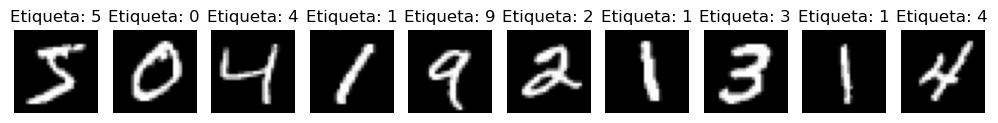

In [4]:
# Carga el dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Muestra las primeras 10 imágenes del conjunto de entrenamiento
plt.figure(figsize=(10, 2))  # Define el tamaño de la figura

for i in range(10):  # Itera sobre las primeras 10 imágenes
    plt.subplot(1, 10, i + 1)  # Crea una subgrilla de 1 fila y 10 columnas
    plt.imshow(x_train[i], cmap='gray')  # Muestra la imagen en escala de grises
    plt.title(f"Etiqueta: {y_train[i]}")  # Título con el número que representa
    plt.axis('off')  # Oculta los ejes

plt.tight_layout()  # Ajusta el espacio entre las imágenes
plt.show()


#Preprocesamiento de los datos

In [5]:
# Parámetros del modelo y de los datos
num_classes = 10           # Tenemos 10 clases posibles (dígitos del 0 al 9). Esto va a ser importante para definir la cantidad de neuronas por capa.
# Como estamos en clasificación, el número de neuronas en la capa final debe coincidir con el número de clases.
input_shape = (28, 28, 1)  # Tamaño de entrada de cada imagen (28x28 píxeles y 1 canal/grayscale de 0 a 255)
# Estamos trabajando con tensores de 3 dimensiones, es decir, alto, ancho y canal.

# Carga los datos MNIST y los divide entre conjunto de entrenamiento y de prueba
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Escala las imágenes para que sus valores estén en el rango [0, 1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Asegura que cada imagen tenga una dimensión adicional para el canal (necesario para la CNN)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Muestra la forma de los datos de entrenamiento
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")  # Cantidad de imágenes en entrenamiento
print(x_test.shape[0], "test samples")    # Cantidad de imágenes en test

# Convierte los vectores de clases en matrices one-hot
# Ej: clase 9 → [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


x (como en x_train, x_test):
Contiene las imágenes en escala de grises de dígitos manuscritos (del 0 al 9).
Cada imagen tiene forma 28x28 píxeles, y cada píxel es un valor entre 0 (negro) y 255 (blanco).

y (como en y_train, y_test):
Contiene las etiquetas (labels) correspondientes a cada imagen.
Son números enteros del 0 al 9, que indican qué número está representado en la imagen.

# Definición e instanciación del modelo

In [6]:
# Se define el modelo como una secuencia de capas
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),  # Capa de entrada: define la forma de las imágenes

        # Primera capa convolucional: 32 filtros de 3x3, activación ReLU.
        # Cada nodo resulta en un mapa de activación, una versión de la imagen que resalta la característica aprendida.
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),

        # Reducción de tamaño mediante max pooling (ventana 2x2)
        # Reduce la dimensión destacando los aspcetos más relevantes de cada sección
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Segunda capa convolucional: 64 filtros de 3x3, activación ReLU
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),

        # Segundo max pooling
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Aplanamiento del resultado para pasar a una capa densa
        # Aplanamiento del tensor 3D (resultado del segundo maxpooling) a un vector de una dimensión.
        layers.Flatten(),

        # Dropout: desactiva aleatoriamente un 50% de neuronas durante el entrenamiento para evitar overfitting
        layers.Dropout(0.5),

        # Capa densa (totalmente conectada): una neurona por clase con softmax para clasificar
        layers.Dense(num_classes, activation="softmax"),
    ]
)

# Muestra un resumen del modelo con la cantidad de parámetros
model.summary()


I0000 00:00:1773266886.386008    1698 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

**Estructura del modelo y funciones de cada capa**


---

- Conv2D

Capa convolucional
Función: Extrae características locales (bordes, formas) de la imagen.

Cómo lo hace: Aplica filtros (o kernels) que recorren la imagen generando mapas de activación.

En tu modelo:

Primera capa: 32 filtros de 3x3 → salida (26, 26, 32)

Segunda capa: 64 filtros de 3x3 → salida (11, 11, 64)


---


- MaxPooling2D

Capa de submuestreo
Función: Reduce la dimensión espacial (ancho y alto) de los mapas, conservando las características más importantes.

Cómo lo hace: Selecciona el valor máximo en regiones pequeñas (en este caso, de 2x2).

Beneficios: Disminuye el costo computacional y ayuda a generalizar.


---


- Flatten

Aplanamiento
Función: Convierte los mapas 3D (alto, ancho, canales) en un vector 1D.

Esto es necesario para conectar con las capas densas (fully connected), que sólo aceptan vectores.


---


- Dropout

Regularización
Función: Previene el sobreajuste.

Cómo lo hace: Durante el entrenamiento, apaga aleatoriamente un % de las neuronas (en este caso, 50%), obligando al modelo a no depender de rutas específicas.


---


- Dense

Capa completamente conectada
Función: Realiza la clasificación final.

Tiene 10 neuronas (una por clase del MNIST) y una función de activación softmax, que da una probabilidad para cada dígito (0 a 9).

# Compilación y entrenamiento del modelo

In [7]:
batch_size = 128  # Cantidad de imágenes procesadas antes de actualizar los pesos
epochs = 15       # Número de pasadas completas al conjunto de entrenamiento

# Compilación del modelo:
# - Función de pérdida para clasificación multiclase
# - Optimizador Adam (adaptativo)
# - Métrica a evaluar: accuracy
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Entrena el modelo usando los datos de entrenamiento
# - Usa el 10% como conjunto de validación
history=model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)


Epoch 1/15


2026-03-11 16:08:21.652437: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 169344000 exceeds 10% of free system memory.
2026-03-11 16:08:22.169653: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 169344000 exceeds 10% of free system memory.
I0000 00:00:1773266903.107262    1758 service.cc:152] XLA service 0x7384740063a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773266903.107305    1758 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-03-11 16:08:23.131593: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773266903.245552    1758 cuda_dnn.cc:529] Loaded cuDNN version 91002


 33/422 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3161 - loss: 2.0869

I0000 00:00:1773266907.330530    1758 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8920 - loss: 0.3586 - val_accuracy: 0.9787 - val_loss: 0.0778
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9666 - loss: 0.1096 - val_accuracy: 0.9838 - val_loss: 0.0551
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9742 - loss: 0.0835 - val_accuracy: 0.9870 - val_loss: 0.0456
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9785 - loss: 0.0698 - val_accuracy: 0.9880 - val_loss: 0.0410
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9809 - loss: 0.0633 - val_accuracy: 0.9880 - val_loss: 0.0379
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9821 - loss: 0.0559 - val_accuracy: 0.9903 - val_loss: 0.0377
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9835 - loss: 0.0504 - val_accuracy: 0.9893 - val_loss: 0.0334
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9844 - loss: 0.0475 - val_accuracy: 0.9893 - va

El entrenamiento se realizó por 15 épocas. A continuación, se destacan algunos aspectos:

Época 1:

Gran salto inicial, indicando que el modelo aprende rápidamente patrones básicos.

Última época (15):


Muy alta precisión, tanto en entrenamiento como validación (no hay sobreajuste evidente).

Tendencia:

La pérdida (loss) disminuye de manera constante.

La precisión (accuracy) en validación sube hasta estabilizarse en torno a 99.2%.

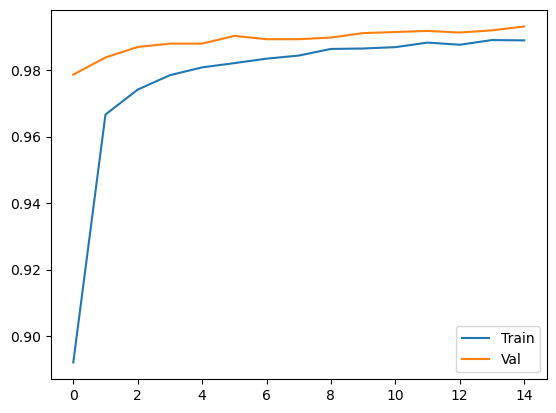

In [8]:
# Visualización de la precisión de entrenamiento y validación durante el entrenamiento
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.show()

# En el eje de las abscisas (x) observamos las épocas y en ordenadas (y) el accuracy del modelo.

# Evaluación del modelo entrenado

In [9]:
# Evalúa el modelo con los datos de prueba y devuelve pérdida y precisión
score = model.evaluate(x_test, y_test, verbose=0)

# Muestra los resultados en el conjunto de prueba
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.02667972445487976
Test accuracy: 0.9904000163078308


 Test Loss: 0.0229
¿Qué es?
Es el valor de la función de pérdida (loss function) calculada sobre el conjunto de prueba (datos que el modelo nunca vio durante el entrenamiento).

¿Cómo interpretarlo?
Cuanto más cercano a 0, mejor. Un valor de 0.0229 indica que el modelo cometió muy pocos errores en sus predicciones durante la evaluación.
➤ Es un muy buen resultado, especialmente si la pérdida también fue baja en validación (como en tu entrenamiento).

Test Accuracy: 0.9921
¿Qué es?
Es el porcentaje de predicciones correctas que el modelo hizo sobre el conjunto de prueba.

¿Cómo interpretarlo?
Una precisión de 99.21% significa que el modelo clasificó correctamente el 99.21% de las imágenes nuevas (fuera del entrenamiento).

➤ Es un resultado excelente, sobre todo si estás trabajando con datos relativamente simples como MNIST o FashionMNIST.

# Evaluación del modelo.

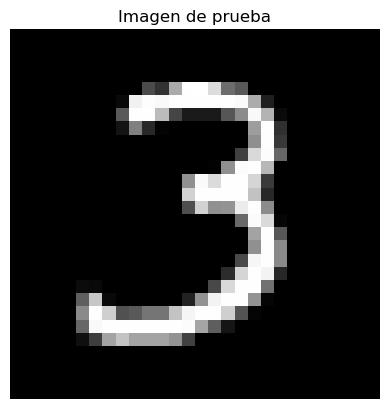

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Etiqueta real     : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Predicción del modelo: 3


In [10]:
# En esta etapa el modelo ya entrenado recibe nuevas imagenes de testeo para ver como predice
# El modelo ya entrenado recibe nuevas imágenes y predice la clase (dígito) que ve
# Este paso es clave para desplegar un modelo en producción, o usarlo con nuevos datos

# Elegimos el índice de la imagen a probar
indice = 2501  # podés cambiar este número para ver otra imagen

# Obtenemos la imagen y su etiqueta real
imagen = x_test[indice]
etiqueta_real = y_test[indice]

# Mostramos la imagen
plt.imshow(imagen.reshape(28, 28), cmap='gray')
plt.title("Imagen de prueba")
plt.axis('off')
plt.show()

# Hacemos la predicción con el modelo (necesitamos agregar una dimensión extra para el batch)
prediccion = model.predict(np.expand_dims(imagen, axis=0))

# Obtenemos la clase predicha (el número con mayor probabilidad)
clase_predicha = np.argmax(prediccion)

# Mostramos resultados
print(f"Etiqueta real     : {etiqueta_real}")
print(f"Predicción del modelo: {clase_predicha}")

# Inferencia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gdown]


Retrieving folder contents


Processing file 1gQr6SHgTvVBz94xY6DXnC-9VY6sf6g60 1.png
Processing file 18lIcADBuhnGLbv1iI8pe2BZ7YT7lKsC2 3.png
Processing file 1o84BPusP4_NTJ90Zq7i6oIQ_gU3iMORM 10232557.png
Processing file 1WcVvnPiRHefVR7PogLH8gS7I7iEtTdO8 animal.jpg
Processing file 1NjAVFjuLFtN-tVq7YSV8x1eQ-3xpOp_3 henquin numero 1.jpg
Processing file 10GRM5llXhcM0KsnMAte0u8TJzXIU7H_b henquin numero 4 ó 9.jpg
Processing file 1ZIZp-6HqAWvR7YOU784KWvFNw8TxjW8Y henquin numero 5.jpg
Processing file 1hgdWt2axtCpSJrhkvWopVEnjyDZSi9Td henquin numero 8 ó 9.jpg
Processing file 18D0yk2Gko3xbc18FDB9RiuW46DinQhLR henquin perro_gato.jpg
Processing file 1RKpt6E3Df53u2A2nj119rTqaCG4glFjM Imagen 100.jpg
Processing file 1YHItDoQlIC352nPfBk1UpjQw9zni1Q5T Numero 9_.jpg
Processing file 1BL1Rl-kMhrSmfDECIMUutR-lsOGMdrr2 Numero 9.jpg
Processing file 1zMvwglMFxL_otJmpnnaD0moCY8412rL2 Perro.jpg
Processing file 1NGkEodK4-FfHTpcG4MjmHNm8ZuXjtONd perro.jpg


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1gQr6SHgTvVBz94xY6DXnC-9VY6sf6g60
To: /home/martin/NUMEROS/1.png
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16.7k/16.7k [00:00<00:00, 1.09MB/s]
Downloading...
From: https://drive.google.com/uc?id=18lIcADBuhnGLbv1iI8pe2BZ7YT7lKsC2
To: /home/martin/NUMEROS/3.png
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14.3k/14.3k [00:00<00:00, 9.11MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o84BPusP4_NTJ90Zq7i6oIQ_gU3iMORM
To: /home/martin/NUMEROS/10232557.png
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.02k/9.02k [00:00<00:00, 186kB/s]
Downloading...
From: https://drive.google.com/uc?id=1WcVvnPiRHefVR

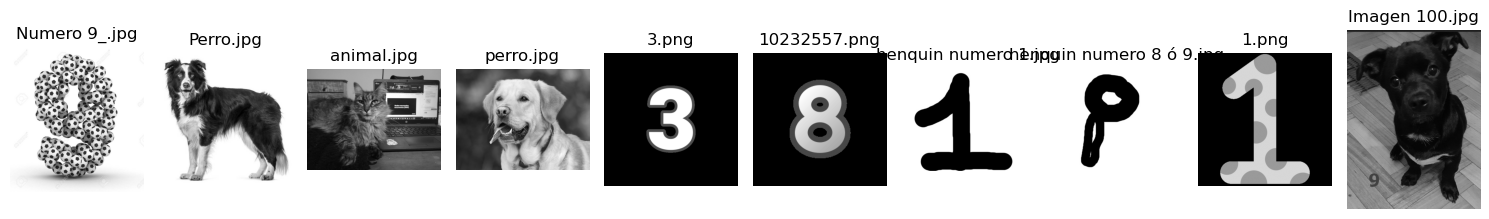

In [11]:
# Instalamos la librería gdown (para descargar archivos de Google Drive) o actualizamos si ya está instalada
!pip install -U gdown

# Importamos la librería gdown para descargas desde Drive
import gdown

# Importamos os para manejo de archivos y directorios
import os

# Importamos PIL (Python Imaging Library) para abrir y manipular imágenes
from PIL import Image

# Importamos matplotlib para graficar imágenes
import matplotlib.pyplot as plt

# ID de la carpeta compartida en Google Drive (debe ser pública para que gdown pueda acceder)
folder_id = '14ZurXcLBL_rE0Ggxzz0XqvTdmTv2l0I6'

# Construimos la URL directa para acceder a esa carpeta de Drive usando su ID
url = f'https://drive.google.com/drive/folders/{folder_id}'

# Descargamos toda la carpeta desde Drive a la máquina local
# quiet=False muestra el progreso, use_cookies=False evita usar cookies para autenticación
gdown.download_folder(url, quiet=False, use_cookies=False)

# Listamos todos los elementos del directorio actual que son carpetas
carpetas = [nombre for nombre in os.listdir() if os.path.isdir(nombre)]

# Inicializamos la variable que contendrá el nombre de la carpeta descargada con imágenes
carpeta_descargada = None

# Iteramos sobre todas las carpetas para encontrar aquella que contenga archivos de imagen
for carpeta in carpetas:
    # Si dentro de la carpeta hay al menos un archivo que termine en .png, .jpg o .jpeg (ignorando mayúsculas/minúsculas)
    if any(archivo.lower().endswith(('.png', '.jpg', '.jpeg')) for archivo in os.listdir(carpeta)):
        # Guardamos el nombre de esa carpeta como la descargada
        carpeta_descargada = carpeta
        # Salimos del ciclo porque ya encontramos la carpeta
        break

# Si no encontramos ninguna carpeta con imágenes, lanzamos un error para informar que algo falló
if carpeta_descargada is None:
    raise FileNotFoundError("No se encontró ninguna carpeta con imágenes descargadas.")

# Listamos todos los archivos de imagen en la carpeta descargada, filtrando por extensiones comunes de imagen
files = [f for f in os.listdir(carpeta_descargada) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Definimos cuántas imágenes mostrar como mínimo entre 10 o la cantidad total disponible
num_images_to_show = min(10, len(files))

# Creamos una figura grande para mostrar las imágenes en fila
plt.figure(figsize=(15, 5))

# Iteramos sobre las primeras imágenes a mostrar, con su índice y nombre de archivo
for i, file_name in enumerate(files[:num_images_to_show]):
    # Construimos la ruta completa a la imagen dentro de la carpeta
    image_path = os.path.join(carpeta_descargada, file_name)
    try:
        # Abrimos la imagen y la convertimos a escala de grises (modo 'L')
        img = Image.open(image_path).convert('L')
        # Creamos un subplot horizontal, donde la posición es i+1
        plt.subplot(1, num_images_to_show, i + 1)
        # Mostramos la imagen en escala de grises
        plt.imshow(img, cmap='gray')
        # Colocamos como título el nombre del archivo
        plt.title(file_name)
        # Quitamos los ejes para mejor visualización
        plt.axis('off')
    except Exception as e:
        # Si no se pudo abrir la imagen, mostramos un mensaje de error indicando cuál falló
        print(f"No se pudo abrir {file_name}: {e}")

# Ajustamos automáticamente los espacios entre subplots para que no se superpongan
plt.tight_layout()

# Mostramos la figura con las imágenes cargadas
plt.show()


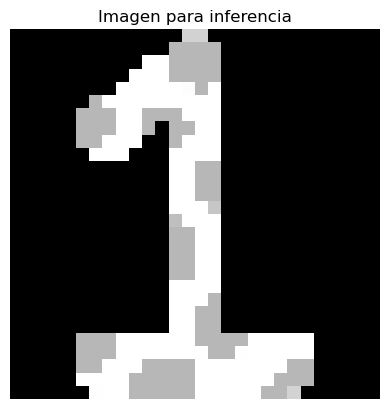

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicción del modelo: 1


In [17]:
# Importamos la librería os para manejo de archivos y directorios
import os

# Importamos numpy para manipulación numérica de arrays
import numpy as np

# Importamos matplotlib para mostrar imágenes
import matplotlib.pyplot as plt

# Importamos funciones de Keras para cargar imágenes y convertirlas a arreglos
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Asignamos la ruta de la carpeta que contiene las imágenes, usando la variable detectada previamente
ruta_carpeta = carpeta_descargada

# Listamos y ordenamos alfabéticamente los archivos de imagen en la carpeta con extensiones comunes
nombres_archivos = sorted([
    archivo for archivo in os.listdir(ruta_carpeta)
    if archivo.lower().endswith(('.png', '.jpg', '.jpeg'))
])

# Definimos el índice de la imagen que queremos cargar para hacer la inferencia
indice = 0  ###################################################################### Podés cambiar este número para probar con otras imágenes

# Construimos la ruta completa hacia la imagen seleccionada
ruta_imagen = os.path.join(ruta_carpeta, nombres_archivos[indice])

# Cargamos la imagen desde la ruta, convirtiéndola a escala de grises y redimensionándola a 28x28 píxeles
imagen = load_img(ruta_imagen, color_mode='grayscale', target_size=(28, 28))

# Mostramos la imagen cargada con un mapa de colores en escala de grises
plt.imshow(imagen, cmap='gray')

# Añadimos un título a la imagen para indicar que es para inferencia
plt.title("Imagen para inferencia")

# Ocultamos los ejes para mejorar la visualización
plt.axis('off')

# Mostramos la imagen en pantalla
plt.show()

# Convertimos la imagen cargada a un arreglo NumPy y normalizamos sus valores dividiéndolos por 255 (escala 0-1)
imagen_array = img_to_array(imagen) / 255.0

# Añadimos una dimensión extra al arreglo para representar el batch (lote) con tamaño 1, requerido por el modelo
imagen_array = np.expand_dims(imagen_array, axis=0)

# Usamos el modelo previamente entrenado para predecir la clase de la imagen procesada
prediccion = model.predict(imagen_array)

# Seleccionamos la clase con mayor probabilidad (el índice del valor máximo en el vector de predicción)
clase_predicha = np.argmax(prediccion)

# Imprimimos la clase que el modelo predijo para la imagen
print(f"Predicción del modelo: {clase_predicha}")


# ¿Qué probabilidad tiene de responder a cada clase?

Predicción del modelo: 1
Probabilidad de la clase predicha: 77.46%
Probabilidades para cada clase:
Clase 0: 0.0000
Clase 1: 0.7746
Clase 2: 0.1938
Clase 3: 0.0313
Clase 4: 0.0000
Clase 5: 0.0000
Clase 6: 0.0000
Clase 7: 0.0001
Clase 8: 0.0000
Clase 9: 0.0001


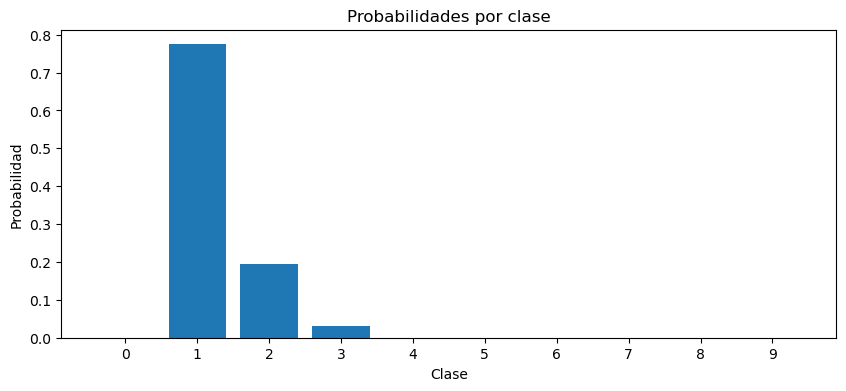

In [18]:


# Mostramos la predicción como antes
print(f"Predicción del modelo: {clase_predicha}")

# Mostramos la probabilidad asociada a esa clase
probabilidad_predicha = np.max(prediccion) * 100
print(f"Probabilidad de la clase predicha: {probabilidad_predicha:.2f}%")

# Mostramos todas las probabilidades (opcional)
print("Probabilidades para cada clase:")
for i, prob in enumerate(prediccion[0]):
    print(f"Clase {i}: {prob:.4f}")

# También podés graficarlas
plt.figure(figsize=(10, 4))
plt.bar(range(len(prediccion[0])), prediccion[0])
plt.title("Probabilidades por clase")
plt.xlabel("Clase")
plt.ylabel("Probabilidad")
plt.xticks(range(len(prediccion[0])))
plt.show()
